In [1]:
!pip install matplotlib seaborn scikit-learn imbalanced-learn xgboost


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install matplotlib seaborn scikit-learn imbalanced-learn xgboost


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
df = pd.read_csv("C:/Users/HP/OneDrive/Desktop/fraud-detection-machine-learning/data/creditcard.csv")

df.shape
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

Class	Meaning	Count
0	Normal transaction	284,315
1	Fraud transaction	492

This confirms the dataset is extremely imbalanced, which is the main challenge in fraud detection.

In [5]:
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Class Imbalance Observation

The dataset is highly imbalanced. Approximately 99.83% of transactions are legitimate, while only 0.17% represent fraudulent transactions. This imbalance can cause machine learning models to become biased toward the majority class, leading to poor fraud detection performance.

Handling this imbalance is therefore critical. In later stages of this project, techniques such as SMOTE (Synthetic Minority Oversampling Technique) will be applied to improve the detection of fraudulent transactions.

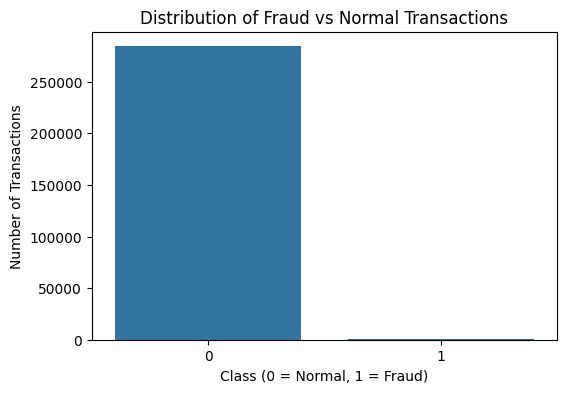

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Distribution of Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

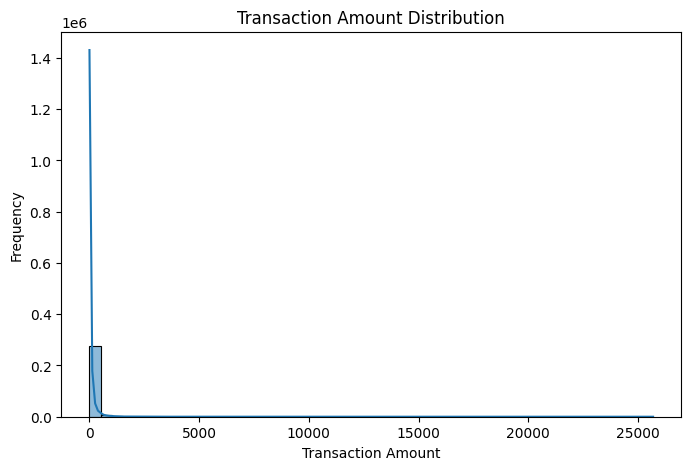

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

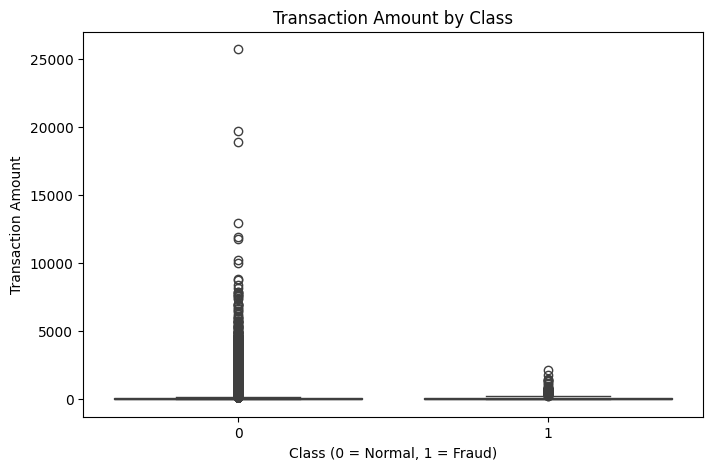

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.show()

Class Imbalance Analysis

The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of all transactions. Specifically, fraud cases account for less than 1% of the total dataset. This imbalance presents a major challenge for machine learning models, as traditional classifiers may become biased toward the majority class.

Handling this imbalance will therefore be a critical step in building effective fraud detection models. Techniques such as SMOTE and undersampling will be applied later in the project to improve model performance.

In [9]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[['Time','Amount']] = scaler.fit_transform(X_train[['Time','Amount']])
X_test[['Time','Amount']] = scaler.transform(X_test[['Time','Amount']])

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9558983554029378


Interpretation of the Baseline Model

Logistic Regression results:

Metric	Class 0 (Normal)	Class 1 (Fraud)
Precision	1.00	0.83
Recall	1.00	0.64
F1-score	1.00	0.72

Total fraud samples in test set:

98
Key observation

the model detected only 64% of fraud cases.

This means:

36% of fraud transactions were missed

In fraud detection, recall is extremely important.

Missing fraud = financial loss.

Interpretation of ROC-AUC

The ROC-AUC:

0.9559

This is already strong, meaning the model can separate fraud vs normal transactions fairly well.

But the recall for fraud is still not good enough.

That is why we now apply SMOTE.

Baseline Model Results

A baseline Logistic Regression model was trained on the original imbalanced dataset. While the model achieved high overall accuracy, the recall for fraudulent transactions was only 0.64, meaning that approximately 36% of fraud cases were not detected.

This highlights the challenge of imbalanced datasets in fraud detection. Because fraudulent transactions represent a very small proportion of the dataset, the model tends to favor the majority class (normal transactions). To address this issue, imbalance-handling techniques such as SMOTE will be applied in the next stage of the project

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [14]:
y_train_smote.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

Now the dataset is balanced.

In [15]:
model_smote = LogisticRegression(max_iter=1000)

model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)
y_prob_smote = model_smote.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9698631105509169


SMOTE Model Results

After applying SMOTE to balance the dataset, the recall for fraudulent transactions increased significantly from 0.64 to 0.92, meaning the model now detects most fraud cases.

However, precision decreased substantially, indicating that many legitimate transactions are incorrectly classified as fraud. This trade-off is common in fraud detection systems, where detecting fraudulent activity (high recall) is often prioritized over minimizing false alarms.

The ROC-AUC score also improved slightly, suggesting that the model’s ability to distinguish between fraudulent and legitimate transactions increased after addressing the class imbalance.

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.973103297664029


Random Forest Model Results

The Random Forest model produced the best performance among the models evaluated so far. It achieved a precision of 0.85 and a recall of 0.84 for fraudulent transactions, resulting in a strong F1-score of 0.84.

Compared to the Logistic Regression models, Random Forest provided a much better balance between detecting fraudulent transactions and minimizing false positives. The ROC-AUC score of 0.973 also indicates excellent discrimination between fraudulent and legitimate transactions.

These results suggest that ensemble models such as Random Forest are well suited for fraud detection tasks because they can capture complex patterns in financial transaction data.

In [17]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.87      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9768807494860635


XGBoost Results Interpretation
results:

Metric	Normal (0)	Fraud (1)
Precision	1.00	0.61
Recall	1.00	0.87
F1-score	1.00	0.71

Fraud detected:

Recall = 0.87

This means the model detected 87% of fraud transactions.

Precision:

0.61

This means some false alarms exist, but fewer than the SMOTE Logistic model.

ROC-AUC

The ROC-AUC:

0.976

This is the best ROC score so far.

It means XGBoost is very strong at separating fraud from normal transactions.

Model Comparison

Now we compare all models.

Model	Precision	Recall	F1-score	ROC-AUC
Baseline Logistic Regression	0.83	0.64	0.72	0.955
SMOTE Logistic Regression	0.06	0.92	0.11	0.969
Random Forest	0.85	0.84	0.84	0.973
XGBoost	0.61	0.87	0.71	0.976
Best Model

For fraud detection:

Random Forest performed best overall because it balances:

✔ precision
✔ recall
✔ F1-score

Model Comparison

Several machine learning models were evaluated to detect fraudulent transactions, including Logistic Regression, Random Forest, and XGBoost. The results show that Random Forest achieved the best balance between precision and recall, resulting in the highest F1-score for fraud detection.

While XGBoost achieved the highest ROC-AUC score, Random Forest provided the most balanced performance in detecting fraudulent transactions while minimizing false positives. This suggests that ensemble learning methods are particularly effective for fraud detection tasks.

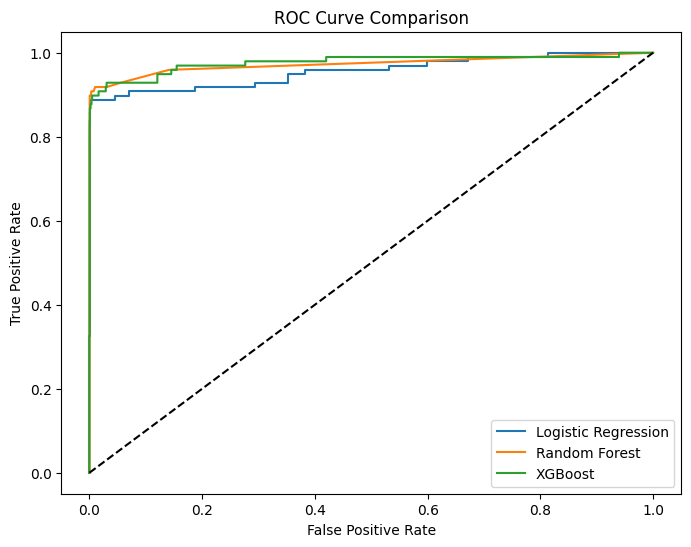

In [18]:
from sklearn.metrics import roc_curve

models = {
    "Logistic Regression": baseline_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

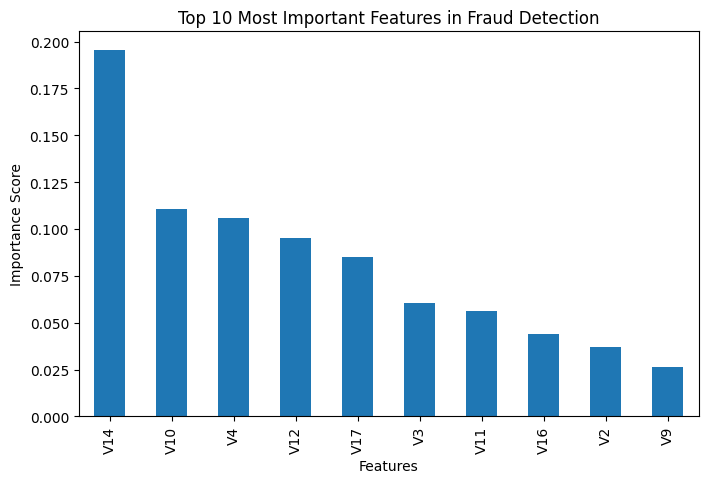

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='bar')
plt.title("Top 10 Most Important Features in Fraud Detection")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.show()

Feature Importance Analysis

To understand which variables contribute most to fraud detection, feature importance was extracted from the Random Forest model. Feature importance helps identify the variables that most strongly influence the model’s predictions.

Understanding feature importance is valuable because it allows financial institutions to focus on the most relevant transaction characteristics when monitoring suspicious activity.

In [20]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

threshold = 0.3
y_pred_threshold = (y_prob_rf >= threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_threshold))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.90      0.81        98

    accuracy                           1.00     56962
   macro avg       0.87      0.95      0.90     56962
weighted avg       1.00      1.00      1.00     56962



Threshold Optimization

In fraud detection systems, adjusting the classification threshold can improve the detection of fraudulent transactions. Instead of using the default probability threshold of 0.5, a lower threshold may be used to detect more fraud cases.

This approach allows financial institutions to prioritize fraud detection, even if it results in a higher number of false alerts that can later be reviewed manually.

In [23]:
import os

os.makedirs("images", exist_ok=True)

In [24]:
plt.savefig("images/feature_importance.png")

<Figure size 640x480 with 0 Axes>

In [25]:
plt.savefig("images/roc_curve.png")

<Figure size 640x480 with 0 Axes>

Conclusion

This project explored the application of machine learning techniques for credit card fraud detection using an imbalanced dataset. Due to the extremely low proportion of fraudulent transactions, imbalance handling techniques such as SMOTE were necessary to improve model performance.

Multiple machine learning models were evaluated, including Logistic Regression, Random Forest, and XGBoost. Among these models, Random Forest achieved the best balance between precision and recall, making it the most suitable model for fraud detection in this dataset.

The results demonstrate that ensemble learning models combined with imbalance-handling techniques can significantly improve the ability to detect fraudulent transactions. Such systems can support financial institutions in reducing financial losses and improving transaction security.

In [27]:
import os
os.getcwd()

'C:\\Users\\HP'